### Select the runtime

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `L4 GPU`, and then click `Save`.

In [1]:
!nvidia-smi

Thu Sep 25 13:44:21 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   64C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [2]:
import os
HOME = os.getcwd()
print("HOME:", HOME)

HOME: /content


### Install dependencies

In [3]:
!pip install -q git+https://github.com/huggingface/transformers.git
!pip install -q git+https://github.com/roboflow/supervision.git
!pip install -q accelerate
!pip install -q roboflow
!pip install -q torchmetrics
!pip install -q "albumentations>=1.4.5"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [25]:
# Cập nhật pip để tránh lỗi dependency
!pip install --upgrade pip

# Cài đặt HuggingFace + Huggingface Hub đồng bộ
!pip install -U transformers==4.44.2 huggingface_hub==0.23.0

# Cài đặt Torchmetrics (cho mAP) và Supervision (cho visualization + metrics)
!pip install torchmetrics==1.4.0 supervision==0.30.0

# Cài Albumentations cho augmentation
!pip install albumentations==1.4.20

# Cài Roboflow SDK (nếu cần tải dataset từ Roboflow)
!pip install roboflow

# Kiểm tra version sau khi cài
!pip show transformers huggingface_hub torchmetrics supervision albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 35.5 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
  Using cached transformers-4.44.2-py3-none-any.whl.metadata (43 kB)
  Using cached huggingface_hub-0.23.0-py3-none-any.whl.metadata (12 kB)
INFO: pip is looking at multiple versions of transformers to determine which version is compatible with other requirements. This could take a while.
ERROR: Cannot install huggingface_hub==0.23.0 and transformers==4.44.2 because these package versions have conflicting dependencies.

The conflict is caused by:
    The user requested huggingface_hub==0.23.0
    transformers 4.44.2 depends on huggingface-hub<1.0 and >=0.23.2

To fix this you could try to:
1. loosen the range of package versions you've specified
2. remove package versions to allow pip to attempt to solve the dependency conflict

ERROR: ResolutionImpossible: for help vis

### Imports

In [4]:
import torch
import requests

import numpy as np
import supervision as sv
import albumentations as A

from PIL import Image
from pprint import pprint
from roboflow import Roboflow
from dataclasses import dataclass, replace
from google.colab import userdata
from torch.utils.data import Dataset
from transformers import (
    AutoImageProcessor,
    AutoModelForObjectDetection,
    TrainingArguments,
    Trainer
)
from torchmetrics.detection.mean_ap import MeanAveragePrecision

## Inference with pre-trained RT-DETR model

In [5]:
# @title Load model Training

CHECKPOINT = "PekingU/rtdetr_r50vd_coco_o365"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModelForObjectDetection.from_pretrained(CHECKPOINT).to(DEVICE)
processor = AutoImageProcessor.from_pretrained(CHECKPOINT)


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/172M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


## Fine-tune RT-DETR on custom dataset

In [6]:
# @title Download dataset from Roboflow Universe

!mkdir {HOME}/datasets
%cd {HOME}/datasets

ROBOFLOW_API_KEY = "viTy1CoKb5ONqV60FChw"

from roboflow import Roboflow
rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("hienlongairesearch").project("chv_dataset_officially")
dataset = project.version(3).download("coco")

mkdir: cannot create directory ‘/content/datasets’: File exists
/content/datasets
loading Roboflow workspace...
loading Roboflow project...


In [7]:
dataset.location

'/content/datasets/CHV_Dataset_officially-3'

In [8]:
ds_train = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/train",
    annotations_path=f"{dataset.location}/train/_annotations.coco.json",
)
ds_valid = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/valid",
    annotations_path=f"{dataset.location}/valid/_annotations.coco.json",
)
ds_test = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/test",
    annotations_path=f"{dataset.location}/test/_annotations.coco.json",
)

print(f"Number of training images: {len(ds_train)}")
print(f"Number of validation images: {len(ds_valid)}")
print(f"Number of test images: {len(ds_test)}")

Number of training images: 1068
Number of validation images: 128
Number of test images: 134


In [9]:
import cv2
import numpy as np

def create_tiles(images, grid_size=(5,5), tile_size=(400,400), pad_color=(255,255,255)):
    rows, cols = grid_size
    h, w = tile_size
    # nền trắng
    grid_img = np.full((rows*h, cols*w, 3), pad_color, dtype=np.uint8)

    for idx, img in enumerate(images):
        if idx >= rows*cols:
            break
        r, c = divmod(idx, cols)
        img_resized = cv2.resize(img, (w,h))
        grid_img[r*h:(r+1)*h, c*w:(c+1)*w] = img_resized

    return grid_img

In [10]:
import cv2
import numpy as np

def create_tiles(images, grid_size=(5,5), tile_size=(400,400), pad_color=(255,255,255)):
    rows, cols = grid_size
    h, w = tile_size
    # nền trắng
    grid_img = np.full((rows*h, cols*w, 3), pad_color, dtype=np.uint8)

    for idx, img in enumerate(images):
        if idx >= rows*cols:
            break
        r, c = divmod(idx, cols)
        img_resized = cv2.resize(img, (w,h))
        grid_img[r*h:(r+1)*h, c*w:(c+1)*w] = img_resized

    return grid_img

### Preprocess the data

To finetune a model, you must preprocess the data you plan to use to match precisely the approach used for the pre-trained model. [AutoImageProcessor](https://huggingface.co/docs/transformers/main/en/model_doc/auto#transformers.AutoImageProcessor) takes care of processing image data to create `pixel_values`, `pixel_mask`, and `labels` that a DETR model can train with. The image processor has some attributes that you won't have to worry about:

- `image_mean = [0.485, 0.456, 0.406 ]`
- `image_std = [0.229, 0.224, 0.225]`

These are the mean and standard deviation used to normalize images during the model pre-training. These values are crucial to replicate when doing inference or finetuning a pre-trained image model.

Instantiate the image processor from the same checkpoint as the model you want to finetune.

In [11]:
IMAGE_SIZE = 480

processor = AutoImageProcessor.from_pretrained(
    CHECKPOINT,
    do_resize=True,
    size={"width": IMAGE_SIZE, "height": IMAGE_SIZE},
)

Before passing the images to the `processor`, apply two preprocessing transformations to the dataset:

- Augmenting images
- Reformatting annotations to meet RT-DETR expectations

First, to make sure the model does not overfit on the training data, you can apply image augmentation with any data augmentation library. Here we use [Albumentations](https://albumentations.ai/docs/). This library ensures that transformations affect the image and update the bounding boxes accordingly.

In [12]:
train_augmentation_and_transform = A.Compose(
    [
        A.Perspective(p=0.1),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.5),
        A.HueSaturationValue(p=0.1),
    ],
    bbox_params=A.BboxParams(
        format="pascal_voc",
        label_fields=["category"],
        clip=True,
        min_area=25
    ),
)

valid_transform = A.Compose(
    [A.NoOp()],
    bbox_params=A.BboxParams(
        format="pascal_voc",
        label_fields=["category"],
        clip=True,
        min_area=1
    ),
)

The `processor` expects the annotations to be in the following format: `{'image_id': int, 'annotations': List[Dict]}`, where each dictionary is a COCO object annotation. Let's add a function to reformat annotations for a single example:

In [13]:
class PyTorchDetectionDataset(Dataset):
    def __init__(self, dataset: sv.DetectionDataset, processor, transform: A.Compose = None):
        self.dataset = dataset
        self.processor = processor
        self.transform = transform

    @staticmethod
    def annotations_as_coco(image_id, categories, boxes):
        annotations = []
        for category, bbox in zip(categories, boxes):
            x1, y1, x2, y2 = bbox
            formatted_annotation = {
                "image_id": image_id,
                "category_id": category,
                "bbox": [x1, y1, x2 - x1, y2 - y1],
                "iscrowd": 0,
                "area": (x2 - x1) * (y2 - y1),
            }
            annotations.append(formatted_annotation)

        return {
            "image_id": image_id,
            "annotations": annotations,
        }

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        _, image, annotations = self.dataset[idx]

        # Convert image to RGB numpy array
        image = image[:, :, ::-1]
        boxes = annotations.xyxy
        categories = annotations.class_id

        if self.transform:
            transformed = self.transform(
                image=image,
                bboxes=boxes,
                category=categories
            )
            image = transformed["image"]
            boxes = transformed["bboxes"]
            categories = transformed["category"]


        formatted_annotations = self.annotations_as_coco(
            image_id=idx, categories=categories, boxes=boxes)
        result = self.processor(
            images=image, annotations=formatted_annotations, return_tensors="pt")

        # Image processor expands batch dimension, lets squeeze it
        result = {k: v[0] for k, v in result.items()}

        return result

Now you can combine the image and annotation transformations to use on a batch of examples:

In [14]:
pytorch_dataset_train = PyTorchDetectionDataset(
    ds_train, processor, transform=train_augmentation_and_transform)
pytorch_dataset_valid = PyTorchDetectionDataset(
    ds_valid, processor, transform=valid_transform)
pytorch_dataset_test = PyTorchDetectionDataset(
    ds_test, processor, transform=valid_transform)

pytorch_dataset_train[15]

{'pixel_values': tensor([[[0.5294, 0.5020, 0.4980,  ..., 0.4902, 0.4824, 0.5059],
          [0.4941, 0.4667, 0.4627,  ..., 0.4431, 0.4353, 0.4588],
          [0.4941, 0.4667, 0.4627,  ..., 0.4431, 0.4353, 0.4588],
          ...,
          [0.7490, 0.7255, 0.6745,  ..., 0.2431, 0.2078, 0.1922],
          [0.3961, 0.4627, 0.4549,  ..., 0.6314, 0.5608, 0.5647],
          [0.2824, 0.1882, 0.2980,  ..., 0.4549, 0.3608, 0.3373]],
 
         [[0.7294, 0.7020, 0.6980,  ..., 0.6627, 0.6627, 0.6980],
          [0.6941, 0.6667, 0.6627,  ..., 0.6196, 0.6196, 0.6510],
          [0.6941, 0.6667, 0.6627,  ..., 0.6196, 0.6196, 0.6510],
          ...,
          [0.7216, 0.6980, 0.6431,  ..., 0.1529, 0.1412, 0.1294],
          [0.3686, 0.4353, 0.4235,  ..., 0.5294, 0.4863, 0.5059],
          [0.2549, 0.1569, 0.2627,  ..., 0.3529, 0.2941, 0.2863]],
 
         [[0.8627, 0.8588, 0.8588,  ..., 0.8392, 0.8314, 0.8549],
          [0.8510, 0.8314, 0.8275,  ..., 0.7922, 0.7843, 0.8157],
          [0.8510, 0.831

You have successfully augmented the images and prepared their annotations. In the final step, create a custom collate_fn to batch images together.

In [15]:
def collate_fn(batch):
    data = {}
    data["pixel_values"] = torch.stack([x["pixel_values"] for x in batch])
    data["labels"] = [x["labels"] for x in batch]
    return data

## Preparing function to compute mAP

In [16]:
id2label = {id: label for id, label in enumerate(ds_train.classes)}
label2id = {label: id for id, label in enumerate(ds_train.classes)}


@dataclass
class ModelOutput:
    logits: torch.Tensor
    pred_boxes: torch.Tensor


class MAPEvaluator:

    def __init__(self, image_processor, threshold=0.00, id2label=None):
        self.image_processor = image_processor
        self.threshold = threshold
        self.id2label = id2label

    def collect_image_sizes(self, targets):
        """Collect image sizes across the dataset as list of tensors with shape [batch_size, 2]."""
        image_sizes = []
        for batch in targets:
            batch_image_sizes = torch.tensor(np.array([x["size"] for x in batch]))
            image_sizes.append(batch_image_sizes)
        return image_sizes

    def collect_targets(self, targets, image_sizes):
        post_processed_targets = []
        for target_batch, image_size_batch in zip(targets, image_sizes):
            for target, (height, width) in zip(target_batch, image_size_batch):
                boxes = target["boxes"]
                boxes = sv.xcycwh_to_xyxy(boxes)
                boxes = boxes * np.array([width, height, width, height])
                boxes = torch.tensor(boxes)
                labels = torch.tensor(target["class_labels"])
                post_processed_targets.append({"boxes": boxes, "labels": labels})
        return post_processed_targets

    def collect_predictions(self, predictions, image_sizes):
        post_processed_predictions = []
        for batch, target_sizes in zip(predictions, image_sizes):
            batch_logits, batch_boxes = batch[1], batch[2]
            output = ModelOutput(logits=torch.tensor(batch_logits), pred_boxes=torch.tensor(batch_boxes))
            post_processed_output = self.image_processor.post_process_object_detection(
                output, threshold=self.threshold, target_sizes=target_sizes
            )
            post_processed_predictions.extend(post_processed_output)
        return post_processed_predictions

    @torch.no_grad()
    def __call__(self, evaluation_results):

        predictions, targets = evaluation_results.predictions, evaluation_results.label_ids

        image_sizes = self.collect_image_sizes(targets)
        post_processed_targets = self.collect_targets(targets, image_sizes)
        post_processed_predictions = self.collect_predictions(predictions, image_sizes)

        evaluator = MeanAveragePrecision(box_format="xyxy", class_metrics=True)
        evaluator.warn_on_many_detections = False
        evaluator.update(post_processed_predictions, post_processed_targets)

        metrics = evaluator.compute()

        # Replace list of per class metrics with separate metric for each class
        classes = metrics.pop("classes")
        map_per_class = metrics.pop("map_per_class")
        mar_100_per_class = metrics.pop("mar_100_per_class")
        for class_id, class_map, class_mar in zip(classes, map_per_class, mar_100_per_class):
            class_name = id2label[class_id.item()] if id2label is not None else class_id.item()
            metrics[f"map_{class_name}"] = class_map
            metrics[f"mar_100_{class_name}"] = class_mar

        metrics = {k: round(v.item(), 4) for k, v in metrics.items()}

        return metrics

eval_compute_metrics_fn = MAPEvaluator(image_processor=processor, threshold=0.01, id2label=id2label)

## Training the detection model

You have done most of the heavy lifting in the previous sections, so now you are ready to train your model! The images in this dataset are still quite large, even after resizing. This means that finetuning this model will require at least one GPU.

Training involves the following steps:

- Load the model with [`AutoModelForObjectDetection`](https://huggingface.co/docs/transformers/main/en/model_doc/auto#transformers.AutoModelForObjectDetection) using the same checkpoint as in the preprocessing.
- Define your training hyperparameters in [`TrainingArguments`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.TrainingArguments).
- Pass the training arguments to [`Trainer`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Trainer) along with the model, dataset, image processor, and data collator.
- Call [`train()`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Trainer.train) to finetune your model.

When loading the model from the same checkpoint that you used for the preprocessing, remember to pass the `label2id` and `id2label` maps that you created earlier from the dataset's metadata. Additionally, we specify `ignore_mismatched_sizes=True` to replace the existing classification head with a new one.

In [17]:
model = AutoModelForObjectDetection.from_pretrained(
    "/content/grive/MyDrive/RT_DETR/kq/checkpoint-9983",
    id2label=id2label,
    label2id=label2id,
    anchor_image_size=None,
    ignore_mismatched_sizes=True,
)

In [18]:
from google.colab import drive
drive.mount('/content/grive')

Drive already mounted at /content/grive; to attempt to forcibly remount, call drive.mount("/content/grive", force_remount=True).


In the [`TrainingArguments`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.TrainingArguments) use `output_dir` to specify where to save your model, then configure hyperparameters as you see fit. For `num_train_epochs=10` training will take about 15 minutes in Google Colab T4 GPU, increase the number of epoch to get better results.

Important notes:

- Do not remove unused columns because this will drop the image column. Without the image column, you can't create `pixel_values`. For this reason, set `remove_unused_columns` to `False`.
- Set `eval_do_concat_batches=False` to get proper evaluation results. Images have different number of target boxes, if batches are concatenated we will not be able to determine which boxes belongs to particular image.

In [23]:
training_args = TrainingArguments(
    output_dir="/content/grive/MyDrive/RT_DETR/kq",
    num_train_epochs=200,
    max_grad_norm=0.1,
    learning_rate=5e-5,
    warmup_steps=300,
    per_device_train_batch_size=16,
    dataloader_num_workers=2,
    metric_for_best_model="eval_map",
    greater_is_better=True,
    load_best_model_at_end=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    remove_unused_columns=False,
    eval_do_concat_batches=False,
    report_to="none"
)

Finally, bring everything together, and call [`train()`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Trainer.train):

In [24]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=pytorch_dataset_train,
    eval_dataset=pytorch_dataset_valid,
    tokenizer=processor,
    data_collator=collate_fn,
    compute_metrics=eval_compute_metrics_fn,
)

trainer.train()

`tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.


Epoch,Training Loss,Validation Loss,Map,Map 50,Map 75,Map Small,Map Medium,Map Large,Mar 1,Mar 10,Mar 100,Mar Small,Mar Medium,Mar Large,Map Ppe,Mar 100 Ppe,Map 0,Mar 100 0,Map 1,Mar 100 1,Map 2,Mar 100 2,Map 3,Mar 100 3,Map 4,Mar 100 4,Map 5,Mar 100 5
1,No log,41.717522,0.051300,0.098400,0.045900,0.007700,0.052200,0.086400,0.058000,0.173400,0.188400,0.059300,0.214200,0.416600,-1.000000,-1.000000,0.281400,0.428100,0.010600,0.228700,0.002600,0.167600,0.000100,0.032600,0.008900,0.165400,0.004200,0.107700
2,No log,24.950056,0.130600,0.226000,0.127100,0.040400,0.158100,0.288800,0.160300,0.330000,0.339700,0.119200,0.474000,0.707000,-1.000000,-1.000000,0.420900,0.545300,0.194600,0.444300,0.005800,0.208800,0.025200,0.271700,0.099500,0.297100,0.037300,0.270800
3,No log,16.379438,0.253200,0.426300,0.272700,0.108400,0.346700,0.500300,0.233300,0.464000,0.474600,0.222700,0.667000,0.860700,-1.000000,-1.000000,0.445200,0.586200,0.316600,0.483500,0.048300,0.355900,0.094600,0.389100,0.410800,0.568300,0.203400,0.464600
4,No log,10.843500,0.334900,0.591500,0.325500,0.202400,0.505900,0.620800,0.295600,0.575800,0.601700,0.410100,0.738700,0.888400,-1.000000,-1.000000,0.436300,0.639000,0.225400,0.568700,0.140300,0.497100,0.222700,0.576100,0.503200,0.675000,0.481500,0.654600
5,No log,9.741291,0.381000,0.683400,0.371700,0.225900,0.593900,0.742700,0.307000,0.587800,0.611700,0.425500,0.738500,0.854800,-1.000000,-1.000000,0.487900,0.651900,0.255100,0.585200,0.283300,0.523500,0.336200,0.589100,0.462800,0.672100,0.460500,0.648500
6,No log,9.231556,0.395900,0.730900,0.393400,0.250700,0.588800,0.811300,0.322000,0.605700,0.621600,0.442300,0.751500,0.875100,-1.000000,-1.000000,0.499500,0.684500,0.277800,0.595700,0.183300,0.502900,0.367700,0.619600,0.537000,0.676000,0.510300,0.650800
7,No log,8.976084,0.421300,0.750900,0.436900,0.271700,0.591100,0.814200,0.325200,0.608400,0.631600,0.460800,0.752600,0.860400,-1.000000,-1.000000,0.502500,0.684200,0.354600,0.633000,0.217500,0.514700,0.415100,0.610900,0.511400,0.684600,0.526900,0.662300
8,30.357600,9.063781,0.391800,0.711000,0.399700,0.257900,0.582100,0.791400,0.328000,0.609100,0.633900,0.461000,0.752200,0.864000,-1.000000,-1.000000,0.486800,0.681900,0.328500,0.627800,0.196900,0.523500,0.348300,0.613000,0.518900,0.694200,0.471400,0.663100
9,30.357600,8.923521,0.426400,0.753900,0.433100,0.285900,0.613300,0.754700,0.322700,0.599500,0.623700,0.465800,0.728000,0.852100,-1.000000,-1.000000,0.513100,0.668800,0.336100,0.610400,0.290300,0.517600,0.388500,0.604300,0.540200,0.692300,0.490400,0.648500
10,30.357600,8.890771,0.436100,0.780600,0.443400,0.275700,0.624800,0.785400,0.324900,0.609100,0.635300,0.464200,0.749400,0.867400,-1.000000,-1.000000,0.526000,0.690500,0.334000,0.602600,0.294300,0.535300,0.391300,0.623900,0.552300,0.694200,0.518900,0.665400


Epoch,Training Loss,Validation Loss,Map,Map 50,Map 75,Map Small,Map Medium,Map Large,Mar 1,Mar 10,Mar 100,Mar Small,Mar Medium,Mar Large,Map Ppe,Mar 100 Ppe,Map 0,Mar 100 0,Map 1,Mar 100 1,Map 2,Mar 100 2,Map 3,Mar 100 3,Map 4,Mar 100 4,Map 5,Mar 100 5
1,No log,41.717522,0.051300,0.098400,0.045900,0.007700,0.052200,0.086400,0.058000,0.173400,0.188400,0.059300,0.214200,0.416600,-1.000000,-1.000000,0.281400,0.428100,0.010600,0.228700,0.002600,0.167600,0.000100,0.032600,0.008900,0.165400,0.004200,0.107700
2,No log,24.950056,0.130600,0.226000,0.127100,0.040400,0.158100,0.288800,0.160300,0.330000,0.339700,0.119200,0.474000,0.707000,-1.000000,-1.000000,0.420900,0.545300,0.194600,0.444300,0.005800,0.208800,0.025200,0.271700,0.099500,0.297100,0.037300,0.270800
3,No log,16.379438,0.253200,0.426300,0.272700,0.108400,0.346700,0.500300,0.233300,0.464000,0.474600,0.222700,0.667000,0.860700,-1.000000,-1.000000,0.445200,0.586200,0.316600,0.483500,0.048300,0.355900,0.094600,0.389100,0.410800,0.568300,0.203400,0.464600
4,No log,10.843500,0.334900,0.591500,0.325500,0.202400,0.505900,0.620800,0.295600,0.575800,0.601700,0.410100,0.738700,0.888400,-1.000000,-1.000000,0.436300,0.639000,0.225400,0.568700,0.140300,0.497100,0.222700,0.576100,0.503200,0.675000,0.481500,0.654600
5,No log,9.741291,0.381000,0.683400,0.371700,0.225900,0.593900,0.742700,0.307000,0.587800,0.611700,0.425500,0.738500,0.854800,-1.000000,-1.000000,0.487900,0.651900,0.255100,0.585200,0.283300,0.523500,0.336200,0.589100,0.462800,0.672100,0.460500,0.648500
6,No log,9.231556,0.395900,0.730900,0.393400,0.250700,0.588800,0.811300,0.322000,0.605700,0.621600,0.442300,0.751500,0.875100,-1.000000,-1.000000,0.499500,0.684500,0.277800,0.595700,0.183300,0.502900,0.367700,0.619600,0.537000,0.676000,0.510300,0.650800
7,No log,8.976084,0.421300,0.750900,0.436900,0.271700,0.591100,0.814200,0.325200,0.608400,0.631600,0.460800,0.752600,0.860400,-1.000000,-1.000000,0.502500,0.684200,0.354600,0.633000,0.217500,0.514700,0.415100,0.610900,0.511400,0.684600,0.526900,0.662300
8,30.357600,9.063781,0.391800,0.711000,0.399700,0.257900,0.582100,0.791400,0.328000,0.609100,0.633900,0.461000,0.752200,0.864000,-1.000000,-1.000000,0.486800,0.681900,0.328500,0.627800,0.196900,0.523500,0.348300,0.613000,0.518900,0.694200,0.471400,0.663100
9,30.357600,8.923521,0.426400,0.753900,0.433100,0.285900,0.613300,0.754700,0.322700,0.599500,0.623700,0.465800,0.728000,0.852100,-1.000000,-1.000000,0.513100,0.668800,0.336100,0.610400,0.290300,0.517600,0.388500,0.604300,0.540200,0.692300,0.490400,0.648500
10,30.357600,8.890771,0.436100,0.780600,0.443400,0.275700,0.624800,0.785400,0.324900,0.609100,0.635300,0.464200,0.749400,0.867400,-1.000000,-1.000000,0.526000,0.690500,0.334000,0.602600,0.294300,0.535300,0.391300,0.623900,0.552300,0.694200,0.518900,0.665400


There were missing keys in the checkpoint model loaded: ['class_embed.0.weight', 'class_embed.0.bias', 'class_embed.1.weight', 'class_embed.1.bias', 'class_embed.2.weight', 'class_embed.2.bias', 'class_embed.3.weight', 'class_embed.3.bias', 'class_embed.4.weight', 'class_embed.4.bias', 'class_embed.5.weight', 'class_embed.5.bias', 'bbox_embed.0.layers.0.weight', 'bbox_embed.0.layers.0.bias', 'bbox_embed.0.layers.1.weight', 'bbox_embed.0.layers.1.bias', 'bbox_embed.0.layers.2.weight', 'bbox_embed.0.layers.2.bias', 'bbox_embed.1.layers.0.weight', 'bbox_embed.1.layers.0.bias', 'bbox_embed.1.layers.1.weight', 'bbox_embed.1.layers.1.bias', 'bbox_embed.1.layers.2.weight', 'bbox_embed.1.layers.2.bias', 'bbox_embed.2.layers.0.weight', 'bbox_embed.2.layers.0.bias', 'bbox_embed.2.layers.1.weight', 'bbox_embed.2.layers.1.bias', 'bbox_embed.2.layers.2.weight', 'bbox_embed.2.layers.2.bias', 'bbox_embed.3.layers.0.weight', 'bbox_embed.3.layers.0.bias', 'bbox_embed.3.layers.1.weight', 'bbox_embed.3.l

TrainOutput(global_step=13400, training_loss=8.52380177967584, metrics={'train_runtime': 22176.1692, 'train_samples_per_second': 9.632, 'train_steps_per_second': 0.604, 'total_flos': 3.786027154403328e+19, 'train_loss': 8.52380177967584, 'epoch': 200.0})

In [33]:
from transformers import AutoModelForObjectDetection  # hoặc AutoModelForSequenceClassification tùy task
import torch

# load checkpoint cuối cùng
model = AutoModelForObjectDetection.from_pretrained("/content/grive/MyDrive/RT_DETR/kq/checkpoint-9983")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [21]:
model = model.to(DEVICE)

## Evaluate

In [27]:
# @title Collect predictions

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


targets = []
predictions = []

for i in range(len(ds_test)):
    path, sourece_image, annotations = ds_test[i]

    image = Image.open(path)
    inputs = processor(image, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    w, h = image.size
    results = processor.post_process_object_detection(
        outputs, target_sizes=[(h, w)], threshold=0.01)

    detections = sv.Detections.from_transformers(results[0])

    targets.append(annotations)
    predictions.append(detections)

In [28]:
# @title Calculate mAP
mean_average_precision = sv.MeanAveragePrecision.from_detections(
    predictions=predictions,
    targets=targets,
)

print(f"map50_95: {mean_average_precision.map50_95:.2f}")
print(f"map50: {mean_average_precision.map50:.2f}")
print(f"map75: {mean_average_precision.map75:.2f}")

map50_95: 0.45
map50: 0.83
map75: 0.44


MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_average_precision.MeanAveragePrecision` instead. The deprecated implementation provides results that are inconsistent with pycocotools.


In [24]:
print(predictions[0])
print(targets[0])

Detections(xyxy=array([], shape=(0, 4), dtype=float32), mask=None, confidence=array([], dtype=float32), class_id=array([], dtype=int64), tracker_id=None, data={}, metadata={})
Detections(xyxy=array([[181,  31, 289, 101],
       [144, 146, 316, 328],
       [140,  30, 325, 328]]), mask=None, confidence=None, class_id=array([5, 2, 1]), tracker_id=None, data={'iscrowd': array([0, 0, 0]), 'area': array([ 7560., 31304., 55130.])}, metadata={})


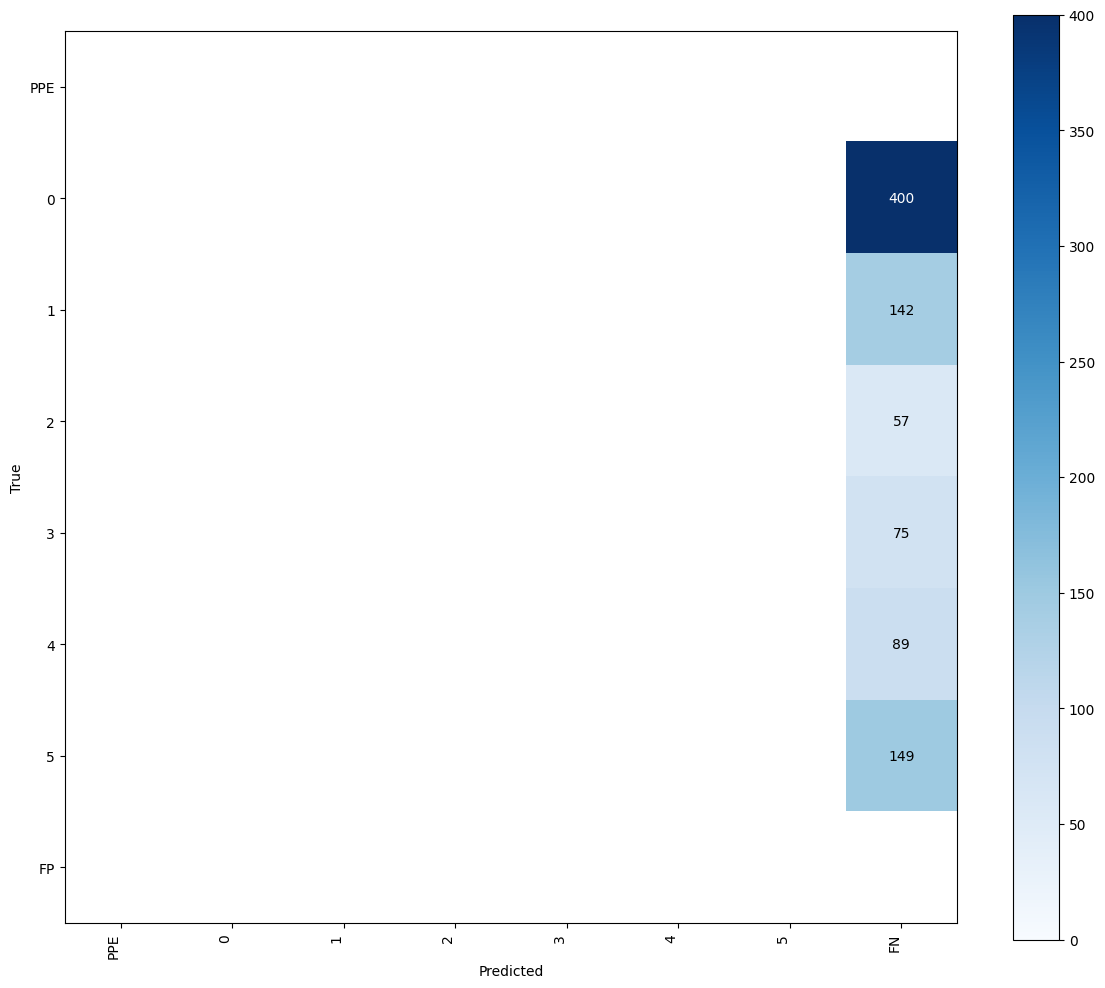

In [29]:
# @title Calculate Confusion Matrix
confusion_matrix = sv.ConfusionMatrix.from_detections(
    predictions=predictions,
    targets=targets,
    classes=ds_test.classes
)

_ = confusion_matrix.plot()